In [1]:
import time
import numpy as np
import pandas as pd

from tensorflow.keras.datasets import mnist, cifar10

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

%matplotlib inline

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# 0. Understanding Optimizers

Recently I had an interview question for Deep Learning candidates, and they were not able to answer these questions. 

Write one paragraph with the help of ChatGPT (or equivalent) explaining each one of the following optimizers, and in the last paragraph, reviewed by the notes from the lab last week, write a comparison of the advantages and disadvantages of each one.  Please note that ChatGPT may hallucinate, so you need to double-check what ChatGPT answers. 

## Stochastic Gradient Descent

An optimization algorithm used to train machine learning models by iteratively adjusting model parameters to minimize a loss function. Instead of computing the gradient of the loss using the entire dataset (as in batch gradient descent), SGD approximates the gradient using a single training example or a small random mini-batch at each step, which makes updates much faster and more scalable for large datasets. This randomness introduces noise into the updates, causing the loss to fluctuate rather than decrease smoothly, but it also helps the algorithm escape shallow local minima and saddle points. Over many iterations, and with an appropriately chosen learning rate (often decayed over time), SGD converges to a good solution that closely minimizes the loss.

## SGD with momentum

An extension of standard SGD that accelerates learning and reduces oscillations by accumulating a velocity vector in parameter space. Instead of updating parameters using only the current gradient, momentum maintains an exponentially decaying moving average of past gradients, so updates build speed in directions with consistent descent and are damped in directions where gradients frequently change sign. This allows the optimizer to move faster along shallow, consistent slopes while smoothing out noisy updates caused by stochastic mini-batches, leading to quicker convergence and more stable training.

## RMSProp

Root Mean Square Propagation is an adaptive learning rate optimization algorithm designed to improve the stability and speed of stochastic gradient descent, especially for non-stationary and noisy problems. It works by maintaining an exponentially decaying average of the squared gradients for each parameter and scaling the learning rate by the inverse of the root of this average, so parameters with large gradients receive smaller updates while those with smaller gradients receive larger ones. This normalization prevents the learning rate from becoming too large or too small in any single direction, reduces oscillations, and enables faster, more reliable convergence compared to standard SGD with a fixed learning rate.

## Adadelta

An adaptive learning rate optimization algorithm that improves upon Adagrad by addressing its rapidly diminishing learning rates. Instead of accumulating all past squared gradients, Adadelta keeps an exponentially decaying average of recent squared gradients and uses this to scale parameter updates, eliminating the need for a manually specified global learning rate. By also maintaining a similar running average of past parameter updates, Adadelta ensures that update magnitudes are consistent with parameter scales, making training more robust and less sensitive to hyperparameter tuning while remaining effective for noisy and non-stationary optimization problems.

## Adam

Adaptive Moment Estimation is a widely used optimization algorithm in deep learning that combines the benefits of momentum and RMSProp to achieve fast and stable convergence. It maintains exponentially decaying estimates of both the first moment (the mean of gradients, like momentum) and the second moment (the uncentered variance of gradients, like RMSProp), and applies bias correction to account for their initialization at zero. By adaptively adjusting the learning rate for each parameter based on these moment estimates, Adam performs well on noisy, sparse, and high-dimensional problems, often requiring little tuning and making it a strong default choice for training deep neural networks.


## Adam with warmup

A variant of the Adam optimizer in which the learning rate is gradually increased from a very small value to its target value over an initial warmup period before following the normal Adam learning rate schedule. This warmup phase helps stabilize training in deep networks by preventing excessively large parameter updates early on, when gradient estimates and Adam’s moment statistics are still unreliable. Once the warmup is complete, Adam proceeds with its adaptive, moment-based updates, resulting in smoother early training, improved convergence, and better performance in large-scale or sensitive models such as transformers.

# 1. Optimizers

In this lab, we will implement some optimizers and see how they behave.

## 1.1. Solving $A x = b$

In [2]:
A = np.array([[2,1,3],[2,6,8],[6,8,18]]).astype(np.float32)
b = np.array([[1],[3],[5]]).astype(np.float32)

In [3]:
np.dot(np.linalg.inv(A), b).shape

(3, 1)

In [4]:
# this is the optimization function.
# we want to obtain x so that (Ax - b)**2 is minimized.

def F(x):
  # (3,3) x (3,1) - (3,1) -> (3, 1)
  return np.dot(A,x) - b

# definition of loss function (MSE of F(x))

def L(x):
  # (1,3) x (3,1) -> (1,1)
  return np.dot(F(x).T, F(x))

# definition of gradient d(MSE(F(x))/dx
def g(x): # numerator gradient.T
   return 2.0 * np.dot(A.T, F(x))

In [5]:
# plot loss over time until it converges

def GD(x, alpha, N=10000, step=500, verbose=False):
  """Implementation of gradient descent loop."""
  i = 0
  history = []

  while i < N:
    x = x - alpha * g(x)
    loss = np.max(np.abs(L(x)))
    history.append(loss)
    if verbose and i % step == 0:
      print(i, np.round(loss,4), np.round(x.flatten(), 2))
    i += 1
    if loss < 1e-4:
      break

  return x, history

def Momentum(x, alpha, beta, N=10000, step=500, verbose=False):
  """
  Momentum GD:
    v_t = beta * v_{t-1} + grad
    x   = x - alpha * v_t
  """
  i = 0
  history = []
  v = np.zeros_like(x)

  while i < N:
    grad = g(x)
    v = beta * v + grad
    x = x - alpha * v

    loss = np.max(np.abs(L(x)))
    history.append(loss)
    if verbose and i % step == 0:
      print(i, np.round(loss, 4), np.round(x.flatten(), 2))
    i += 1
    if loss < 1e-4:
      break

  return x, history

def Adadelta(x, beta, N=10000, step=500, eps=1e-8, verbose=False):
  """
  Adadelta (no explicit global learning rate):
    Eg   = beta*Eg + (1-beta)*g^2
    dx   = - (sqrt(Edx+eps) / sqrt(Eg+eps)) * g
    Edx  = beta*Edx + (1-beta)*dx^2
    x    = x + dx
  """
  i = 0
  history = []
  Eg = np.zeros_like(x)
  Edx = np.zeros_like(x)

  while i < N:
    grad = g(x)
    Eg = beta * Eg + (1.0 - beta) * (grad ** 2)

    rms_dx = np.sqrt(Edx + eps)
    rms_g = np.sqrt(Eg + eps)
    dx = - (rms_dx / rms_g) * grad

    Edx = beta * Edx + (1.0 - beta) * (dx ** 2)
    x = x + dx

    loss = np.max(np.abs(L(x)))
    history.append(loss)
    if verbose and i % step == 0:
      print(i, np.round(loss, 4), np.round(x.flatten(), 2))
    i += 1
    if loss < 1e-4:
      break

  return x, history

def Adam(x, alpha, beta1, beta2, N=10000, step=500, eps=1e-8, verbose=False):
  """
  Adam:
    m = beta1*m + (1-beta1)*g
    v = beta2*v + (1-beta2)*g^2
    mhat = m / (1-beta1^t)
    vhat = v / (1-beta2^t)
    x = x - alpha * mhat / (sqrt(vhat)+eps)
  """
  i = 0
  history = []
  m = np.zeros_like(x)
  v = np.zeros_like(x)

  while i < N:
    t = i + 1
    grad = g(x)

    m = beta1 * m + (1.0 - beta1) * grad
    v = beta2 * v + (1.0 - beta2) * (grad ** 2)

    mhat = m / (1.0 - beta1 ** t)
    vhat = v / (1.0 - beta2 ** t)

    x = x - alpha * mhat / (np.sqrt(vhat) + eps)

    loss = np.max(np.abs(L(x)))
    history.append(loss)
    if verbose and i % step == 0:
      print(i, np.round(loss, 4), np.round(x.flatten(), 2))
    i += 1
    if loss < 1e-4:
      break

  return x, history

# ramp up alpha in the first epochs 0 -> alpha for first ramp_n epochs
def AdamWithWarmup(x, ramp_n, alpha, beta1, beta2, N=10000, step=500, eps=1e-8, verbose=False):
  """
  Adam with linear warmup for the first ramp_n steps:
    alpha_t = alpha * min(1, t / ramp_n)
  """
  i = 0
  history = []
  m = np.zeros_like(x)
  v = np.zeros_like(x)

  while i < N:
    t = i + 1
    grad = g(x)

    m = beta1 * m + (1.0 - beta1) * grad
    v = beta2 * v + (1.0 - beta2) * (grad ** 2)

    mhat = m / (1.0 - beta1 ** t)
    vhat = v / (1.0 - beta2 ** t)

    alpha_t = alpha * min(1.0, t / float(max(1, ramp_n)))
    x = x - alpha_t * mhat / (np.sqrt(vhat) + eps)

    loss = np.max(np.abs(L(x)))
    history.append(loss)
    if verbose and i % step == 0:
      print(i, np.round(loss, 4), np.round(x.flatten(), 2), "alpha_t=", np.round(alpha_t, 6))
    i += 1
    if loss < 1e-4:
      break

  return x, history

In [6]:
x1 = np.random.uniform(-0.01,0.01,size=(3,1))
x2 = np.copy(x1)
x3 = np.copy(x1)
x4 = np.copy(x1)
x5 = np.copy(x1)

In [7]:
x1, history_gd = GD(x1, alpha=0.0002, verbose=True)

0 22.2531 [0.01 0.03 0.04]
500 0.0846 [0.04 0.23 0.17]
1000 0.0548 [0.05 0.27 0.14]
1500 0.0426 [0.07 0.3  0.13]
2000 0.0341 [0.09 0.31 0.11]
2500 0.0274 [0.12 0.32 0.1 ]
3000 0.0221 [0.13 0.33 0.09]
3500 0.0178 [0.15 0.34 0.08]
4000 0.0143 [0.17 0.34 0.07]
4500 0.0115 [0.18 0.35 0.06]
5000 0.0093 [0.19 0.35 0.06]
5500 0.0074 [0.2  0.36 0.05]
6000 0.006 [0.21 0.36 0.05]
6500 0.0048 [0.22 0.37 0.04]
7000 0.0039 [0.23 0.37 0.04]
7500 0.0031 [0.24 0.37 0.03]
8000 0.0025 [0.24 0.38 0.03]
8500 0.002 [0.25 0.38 0.03]
9000 0.0016 [0.25 0.38 0.02]
9500 0.0013 [0.26 0.38 0.02]


In [8]:
x2, history_mo = Momentum(x2, alpha=0.0002, beta=0.90, N=10000, step=500,verbose=True)

0 22.2531 [0.01 0.03 0.04]
500 0.0092 [0.19 0.35 0.06]
1000 0.001 [0.26 0.38 0.02]
1500 0.0001 [0.29 0.4  0.01]


In [9]:
x3, history_add = Adadelta(x3, beta=0.9, verbose=True)

0 35.761 [-0.    0.01 -0.01]
500 0.1916 [0.16 0.17 0.16]
1000 0.0311 [0.13 0.3  0.1 ]
1500 0.0075 [0.21 0.36 0.05]
2000 0.0043 [0.26 0.38 0.02]
2500 0.0054 [0.28 0.39 0.01]
3000 0.0074 [0.29 0.4  0.  ]
3500 0.0095 [ 0.3  0.4 -0. ]
4000 0.0116 [ 0.3  0.4 -0. ]
4500 0.0137 [ 0.3  0.4 -0. ]
5000 0.0158 [ 0.3  0.4 -0. ]
5500 0.0178 [ 0.3   0.4  -0.01]
6000 0.0198 [ 0.3   0.4  -0.01]
6500 0.0219 [ 0.3   0.4  -0.01]
7000 0.0239 [ 0.3   0.4  -0.01]
7500 0.0259 [ 0.3   0.4  -0.01]
8000 0.0279 [ 0.3   0.4  -0.01]
8500 0.0299 [ 0.3   0.4  -0.01]
9000 0.0319 [ 0.3   0.4  -0.01]
9500 0.0339 [ 0.3   0.4  -0.01]


We see the Adadelta model unlearning after 3500 iterations

In [10]:
x4, history_ada = Adam(x4, alpha=0.001, beta1=0.9, beta2=0.999, verbose=True)

0 35.4657 [-0.    0.01 -0.  ]
500 0.1646 [0.15 0.18 0.16]
1000 0.1248 [0.14 0.2  0.15]
1500 0.0878 [0.12 0.23 0.14]
2000 0.0612 [0.11 0.25 0.13]
2500 0.0452 [0.1  0.28 0.13]
3000 0.0358 [0.11 0.29 0.12]
3500 0.029 [0.12 0.31 0.1 ]
4000 0.0229 [0.14 0.32 0.09]
4500 0.0169 [0.16 0.33 0.08]
5000 0.0114 [0.18 0.35 0.07]
5500 0.0069 [0.21 0.36 0.05]
6000 0.0036 [0.23 0.37 0.04]
6500 0.0016 [0.26 0.38 0.02]
7000 0.0005 [0.27 0.39 0.01]
7500 0.0001 [0.29 0.39 0.01]


In [11]:
x5, history_adawu = AdamWithWarmup(x5, ramp_n=100, alpha=0.001, beta1=0.9, beta2=0.999, verbose=True)

0 35.8936 [-0.    0.01 -0.01] alpha_t= 1e-05
500 0.1728 [0.16 0.18 0.16] alpha_t= 0.001
1000 0.1382 [0.14 0.19 0.15] alpha_t= 0.001
1500 0.1039 [0.13 0.21 0.15] alpha_t= 0.001
2000 0.0753 [0.12 0.24 0.14] alpha_t= 0.001
2500 0.0551 [0.11 0.26 0.13] alpha_t= 0.001
3000 0.0426 [0.1  0.28 0.12] alpha_t= 0.001
3500 0.0346 [0.11 0.3  0.11] alpha_t= 0.001
4000 0.0284 [0.12 0.31 0.1 ] alpha_t= 0.001
4500 0.0226 [0.14 0.32 0.09] alpha_t= 0.001
5000 0.0169 [0.16 0.33 0.08] alpha_t= 0.001
5500 0.0116 [0.18 0.35 0.07] alpha_t= 0.001
6000 0.0071 [0.21 0.36 0.05] alpha_t= 0.001
6500 0.0038 [0.23 0.37 0.04] alpha_t= 0.001
7000 0.0017 [0.25 0.38 0.03] alpha_t= 0.001
7500 0.0006 [0.27 0.39 0.02] alpha_t= 0.001
8000 0.0002 [0.29 0.39 0.01] alpha_t= 0.001


"Warmup should use 5-10% of total steps" - https://www.emergentmind.com/topics/learning-rate-warmup

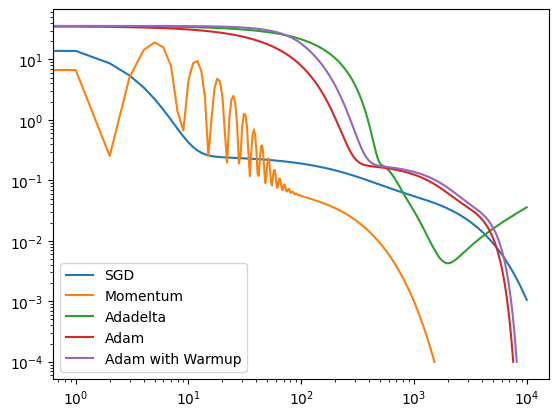

In [12]:
plt.plot(history_gd, label='SGD')
plt.plot(history_mo, label='Momentum')
plt.plot(history_add, label='Adadelta')
plt.plot(history_ada, label='Adam')
plt.plot(history_adawu, label='Adam with Warmup')

plt.xscale('log')   # <-- logarithmic x-axis
plt.yscale('log')   # <-- logarithmic y-axis

plt.legend()
plt.show()

I used a logarithmic scale to better visualize the data. Here we can more clearly see how momentum optimization learns differently to other models, oscillating towards convergence. We can also see the unlearning in Adadelta and the inferior performance of SGD.

In [13]:
# For Ax = b, the solution is (A**-1 * b).T
print("Solution is: ", np.dot(np.linalg.inv(A),b).T)

Solution is:  [[0.30000007 0.39999986 0.        ]]


Adadelta was closest to these values and yet the loss calculated was higher than SGD

## 1.2. Function ${(1-x_0)}^2 + 100 {(x_1 - x_0^2)}^2$ 

### [ Rosenbrock function ]

In [14]:
def F(x):
  return np.power(1-x[0],2) + 100.0*np.power(x[1] - np.power(x[0],2),2)

# definition of loss function (F(x)) - let's see when this function is 0
def L(x):
  return F(x)

# definition of gradient
def g(x):
  return np.array([
    -(1-x[0]) - 100.0*4*x[0]*(x[1] - np.power(x[0],2)),
    100.0*2*(x[1] - np.power(x[0],2))
  ])

In [15]:
x1 = np.random.uniform(-0.01,0.01,size=(2,1))
x2 = np.copy(x1)
x3 = np.copy(x1)
x4 = np.copy(x1)
x5 = np.copy(x1)
alpha = 0.001
beta1 = 0.9
beta2 = 0.999
ramp_n= 100 # As previously defined at 10% total steps

In [16]:
x1, history_gd = GD(x1, alpha, verbose=True)

0 0.9858 [ 0.01 -0.  ]
500 0.4233 [0.35 0.12]
1000 0.24 [0.51 0.26]
1500 0.1543 [0.61 0.37]
2000 0.1058 [0.67 0.45]
2500 0.0756 [0.73 0.53]
3000 0.0554 [0.76 0.58]
3500 0.0414 [0.8  0.63]
4000 0.0315 [0.82 0.68]
4500 0.0242 [0.84 0.71]
5000 0.0187 [0.86 0.74]
5500 0.0146 [0.88 0.77]
6000 0.0115 [0.89 0.8 ]
6500 0.0091 [0.9  0.82]
7000 0.0072 [0.92 0.84]
7500 0.0057 [0.92 0.85]
8000 0.0046 [0.93 0.87]
8500 0.0037 [0.94 0.88]
9000 0.0029 [0.95 0.89]
9500 0.0024 [0.95 0.9 ]


In [17]:
x2, history_mo = Momentum(x2, alpha, beta1, verbose=True)

0 0.9858 [ 0.01 -0.  ]
500 0.0171 [0.87 0.76]
1000 0.0017 [0.96 0.92]
1500 0.0002 [0.99 0.97]


In [18]:
x3, history_add = Adadelta(x3, alpha, verbose=True)

0 0.9875 [ 0.01 -0.  ]
500 0.2221 [0.53 0.28]
1000 0.075 [0.73 0.53]
1500 0.0754 [0.73 0.53]
2000 0.0758 [0.73 0.53]
2500 0.0763 [0.73 0.53]
3000 0.0768 [0.73 0.53]
3500 0.0773 [0.73 0.53]
4000 0.0779 [0.73 0.53]
4500 0.0784 [0.73 0.53]
5000 0.0789 [0.73 0.53]
5500 0.0795 [0.73 0.53]
6000 0.08 [0.73 0.53]
6500 0.0806 [0.73 0.53]
7000 0.0811 [0.73 0.53]
7500 0.0817 [0.73 0.53]
8000 0.0822 [0.73 0.53]
8500 0.0828 [0.73 0.53]
9000 0.0834 [0.73 0.53]
9500 0.0839 [0.73 0.53]


In [19]:
x4, history_ada = Adam(x4, alpha, beta1, beta2, verbose=True)

0 0.9858 [0.01 0.  ]
500 0.3084 [0.44 0.2 ]
1000 0.0666 [0.74 0.55]
1500 0.0086 [0.91 0.82]
2000 0.0006 [0.98 0.95]


In [20]:
x5, history_adawu = AdamWithWarmup(x5, ramp_n, alpha, beta1, beta2, verbose=True)

0 0.9877 [ 0.01 -0.  ] alpha_t= 1e-05
500 0.3572 [0.4  0.16] alpha_t= 0.001
1000 0.0829 [0.71 0.51] alpha_t= 0.001
1500 0.0118 [0.89 0.79] alpha_t= 0.001
2000 0.0009 [0.97 0.94] alpha_t= 0.001


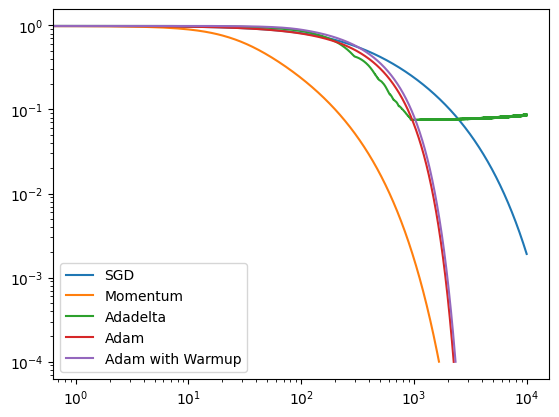

In [21]:
plt.plot(history_gd, label='SGD')
plt.plot(history_mo, label='Momentum')
plt.plot(history_add, label='Adadelta')
plt.plot(history_ada, label='Adam')
plt.plot(history_adawu, label='Adam with Warmup')

plt.xscale('log')   # <-- logarithmic x-axis
plt.yscale('log')   # <-- logarithmic y-axis

plt.legend()
plt.show()

The values did not all converge to the same vector, but the loss was reduced in similar ways. Strangely, we do not see momentum learning oscillating here. Adam with Warmup also does not show increased performance for any of the tested ramp counts.

## 1.3. Deep Learning Package From Lab2

Using the package you created in lab2, define a network and train the loss functions specified before. Plot accuracy of models.

In [60]:
# Deep Learning Package from Lab 2

# Activation functions
def relu(x):
    return x * (x >= 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def linear(x):
    return x

def d_linear(x):
    return np.ones_like(x)

def d_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

def d_relu(x):
    return (x >= 0).astype(np.float32)

activations = {"linear": linear, "relu": relu, "sigmoid": sigmoid}
d_activations = {"linear": d_linear, "relu": d_relu, "sigmoid": d_sigmoid}

def initialize_weights(shapes, outputs):
    """Initializes weights with uniform random [-1,+1] and zero bias."""
    model = []
    for i in range(len(outputs)):
        in_dim, out_dim = shapes[i], shapes[i + 1]
        W = np.random.uniform(-1, 1, size=(in_dim, out_dim))
        b = np.zeros(out_dim)
        model.append([W, b, outputs[i]])
    return model

def forward(x, model):
    """Forward pass through network."""
    result = []
    y = x
    for layer in model:
        z = np.dot(y, layer[0]) + layer[1]
        y = activations[layer[2]](z)
        result.append({'y': y, 'z': z})
    return result

def predict(x, model):
    """Predict output of model."""
    return forward(x, model)[-1]["y"]

def mse(y, p):
    """Mean-Square Error loss."""
    return np.mean((y - p)**2)

def binary_crossentropy(y, p):
    """Binary crossentropy loss."""
    eps = 1e-7
    p = np.clip(p, eps, 1.0 - eps)
    return -np.mean(np.sum(y * np.log(p) + (1 - y) * np.log(1 - p), axis=1))

def backward(y, x, model, loss):
    """Backward pass to compute gradients."""
    cache = forward(x, model)
    p = cache[-1]["y"]
    
    if loss == "mse":
        loss_val = mse(y, p)
        B, No = x.shape[0], y.shape[1]
        dL_dp = (2.0 / (B * No)) * (p - y)
    else:  # binary_crossentropy
        loss_val = binary_crossentropy(y, p)
        eps = 1e-7
        p_clip = np.clip(p, eps, 1.0 - eps)
        B = x.shape[0]
        dL_dp = (1.0 / B) * ((p_clip - y) / (p_clip * (1.0 - p_clip)))
    
    grads = [None] * len(model)
    zL = cache[-1]["z"]
    delta = dL_dp * d_activations[model[-1][2]](zL)
    
    for i in reversed(range(len(model))):
        W, b, act = model[i]
        a_prev = x if i == 0 else cache[i - 1]["y"]
        grads[i] = {"dw": a_prev.T @ delta, "db": np.sum(delta, axis=0)}
        if i > 0:
            z_prev = cache[i - 1]["z"]
            delta = (delta @ W.T) * d_activations[model[i - 1][2]](z_prev)
    
    return loss_val, grads

def accuracy(y, p):
    """Compute classification accuracy."""
    return np.mean(np.argmax(y, axis=-1) == np.argmax(p, axis=-1))

# Load MNIST dataset
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

# Preprocess: flatten and normalize
x_train_full = x_train_full.reshape(-1, 784).astype(np.float32) / 255.0
x_test = x_test.reshape(-1, 784).astype(np.float32) / 255.0

# Use a subset for faster training
n_train = 5000
x_train = x_train_full[:n_train]
y_train_labels = y_train_full[:n_train]

# One-hot encode labels
num_classes = 10
y_train = np.zeros((n_train, num_classes), dtype=np.float32)
y_train[np.arange(n_train), y_train_labels] = 1

# Network architecture: 784 -> 128 -> 64 -> 10
shapes = [784, 128, 64, 10]
outputs = ["relu", "relu", "sigmoid"]

# Training parameters
N_epochs = 100
batch_size = 64
n_batches = n_train // batch_size

# Training function for each optimizer
def train_with_optimizer(optimizer_type, alpha=0.01, beta=0.9, beta1=0.9, beta2=0.999, ramp_n=100):
    np.random.seed(42)
    model = initialize_weights(shapes, outputs)
    history = []
    
    # Initialize optimizer state
    if optimizer_type == "Momentum":
        v = [[np.zeros_like(layer[0]), np.zeros_like(layer[1])] for layer in model]
    elif optimizer_type == "Adadelta":
        Eg = [[np.zeros_like(layer[0]), np.zeros_like(layer[1])] for layer in model]
        Edx = [[np.zeros_like(layer[0]), np.zeros_like(layer[1])] for layer in model]
    elif optimizer_type in ["Adam", "AdamWarmup"]:
        m = [[np.zeros_like(layer[0]), np.zeros_like(layer[1])] for layer in model]
        v = [[np.zeros_like(layer[0]), np.zeros_like(layer[1])] for layer in model]
    
    t = 0
    for epoch in range(N_epochs):
        for batch_idx in range(n_batches):
            start = batch_idx * batch_size
            end = start + batch_size
            x_batch = x_train[start:end]
            y_batch = y_train[start:end]
            
            loss, grads = backward(y_batch, x_batch, model, "binary_crossentropy")
            t += 1
            
            for i in range(len(model)):
                dw, db = grads[i]["dw"], grads[i]["db"]
                
                if optimizer_type == "SGD":
                    model[i][0] -= alpha * dw
                    model[i][1] -= alpha * db
                    
                elif optimizer_type == "Momentum":
                    v[i][0] = beta * v[i][0] + dw
                    v[i][1] = beta * v[i][1] + db
                    model[i][0] -= alpha * v[i][0]
                    model[i][1] -= alpha * v[i][1]
                    
                elif optimizer_type == "Adadelta":
                    eps = 1e-8
                    Eg[i][0] = beta * Eg[i][0] + (1 - beta) * dw**2
                    Eg[i][1] = beta * Eg[i][1] + (1 - beta) * db**2
                    dx_w = -np.sqrt(Edx[i][0] + eps) / np.sqrt(Eg[i][0] + eps) * dw
                    dx_b = -np.sqrt(Edx[i][1] + eps) / np.sqrt(Eg[i][1] + eps) * db
                    Edx[i][0] = beta * Edx[i][0] + (1 - beta) * dx_w**2
                    Edx[i][1] = beta * Edx[i][1] + (1 - beta) * dx_b**2
                    model[i][0] += dx_w
                    model[i][1] += dx_b
                    
                elif optimizer_type in ["Adam", "AdamWarmup"]:
                    eps = 1e-8
                    m[i][0] = beta1 * m[i][0] + (1 - beta1) * dw
                    m[i][1] = beta1 * m[i][1] + (1 - beta1) * db
                    v[i][0] = beta2 * v[i][0] + (1 - beta2) * dw**2
                    v[i][1] = beta2 * v[i][1] + (1 - beta2) * db**2
                    mhat_w = m[i][0] / (1 - beta1**t)
                    mhat_b = m[i][1] / (1 - beta1**t)
                    vhat_w = v[i][0] / (1 - beta2**t)
                    vhat_b = v[i][1] / (1 - beta2**t)
                    alpha_t = alpha * min(1.0, t / max(1, ramp_n)) if optimizer_type == "AdamWarmup" else alpha
                    model[i][0] -= alpha_t * mhat_w / (np.sqrt(vhat_w) + eps)
                    model[i][1] -= alpha_t * mhat_b / (np.sqrt(vhat_b) + eps)
        
        # Compute epoch accuracy
        p = predict(x_train, model)
        acc = accuracy(y_train, p)
        history.append(acc)
        if epoch % 20 == 0:
            print(f"{optimizer_type} - Epoch {epoch}: accuracy = {acc:.4f}")
    
    return model, history

# Train with each optimizer
print("Training with SGD...")
_, history_gd = train_with_optimizer("SGD", alpha=0.1)

print("\nTraining with Momentum...")
_, history_mo = train_with_optimizer("Momentum", alpha=0.0005, beta=0.9)

print("\nTraining with Adadelta...")
_, history_add = train_with_optimizer("Adadelta", beta=0.9)

print("\nTraining with Adam...")
_, history_ada = train_with_optimizer("Adam", alpha=0.001)

print("\nTraining with Adam + Warmup...")
_, history_adawu = train_with_optimizer("AdamWarmup", alpha=0.001, ramp_n=100)

Training with SGD...
SGD - Epoch 0: accuracy = 0.1532


C:\Users\Jaxba\AppData\Local\Temp\ipykernel_8000\2453590537.py:8: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


SGD - Epoch 20: accuracy = 0.7296
SGD - Epoch 40: accuracy = 0.7596
SGD - Epoch 60: accuracy = 0.8684
SGD - Epoch 80: accuracy = 0.8694

Training with Momentum...
Momentum - Epoch 0: accuracy = 0.1684
Momentum - Epoch 20: accuracy = 0.5132
Momentum - Epoch 40: accuracy = 0.6690
Momentum - Epoch 60: accuracy = 0.7396
Momentum - Epoch 80: accuracy = 0.7584

Training with Adadelta...
Adadelta - Epoch 0: accuracy = 0.1402
Adadelta - Epoch 20: accuracy = 0.5334
Adadelta - Epoch 40: accuracy = 0.6440
Adadelta - Epoch 60: accuracy = 0.7468
Adadelta - Epoch 80: accuracy = 0.7638

Training with Adam...
Adam - Epoch 0: accuracy = 0.2724
Adam - Epoch 20: accuracy = 0.6898
Adam - Epoch 40: accuracy = 0.6960
Adam - Epoch 60: accuracy = 0.7058
Adam - Epoch 80: accuracy = 0.7946

Training with Adam + Warmup...
AdamWarmup - Epoch 0: accuracy = 0.1386
AdamWarmup - Epoch 20: accuracy = 0.6926
AdamWarmup - Epoch 40: accuracy = 0.7836
AdamWarmup - Epoch 60: accuracy = 0.7888
AdamWarmup - Epoch 80: accurac

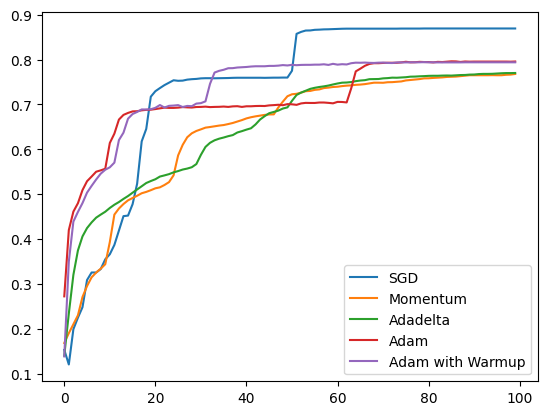

In [61]:
plt.plot(history_gd, label='SGD')
plt.plot(history_mo, label='Momentum')
plt.plot(history_add, label='Adadelta')
plt.plot(history_ada, label='Adam')
plt.plot(history_adawu, label='Adam with Warmup')



plt.legend()
plt.show()

While we see the model training with all optimizer models, Stochastic Gradient Descent comes out to perform as a clear winner reaching nearly 87% accuracy while the other models could not surpass 80% accuracy, but requires longer training. They are particularly sensitive to different learning rate parameters, especially momentum which required a much smaller alpha coefficient in order to learn. The Adam models train significantly faster, with the warmup giving an additional boost in how quickly it converges. 

# 2. Data Visualization

You should look at https://towardsdatascience.com/visualising-high-dimensional-datasets-using-pca-and-t-sne-in-python-8ef87e7915b, which contains a very nice introduction into visualizing datasets using PCA
and tSNE.

In [25]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [26]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [27]:
x_train = x_train / 255.0

To create a permutation of the inputs, we can just permute the indexes.

In [28]:
indexes = x_train.shape[0]
indexes = np.random.permutation(indexes)
indexes

array([ 8144, 53160, 59399, ..., 34788, 54531, 28631],
      shape=(60000,), dtype=int32)

In [29]:
x_train = x_train[indexes]
y_train = y_train[indexes]

<Figure size 640x480 with 0 Axes>

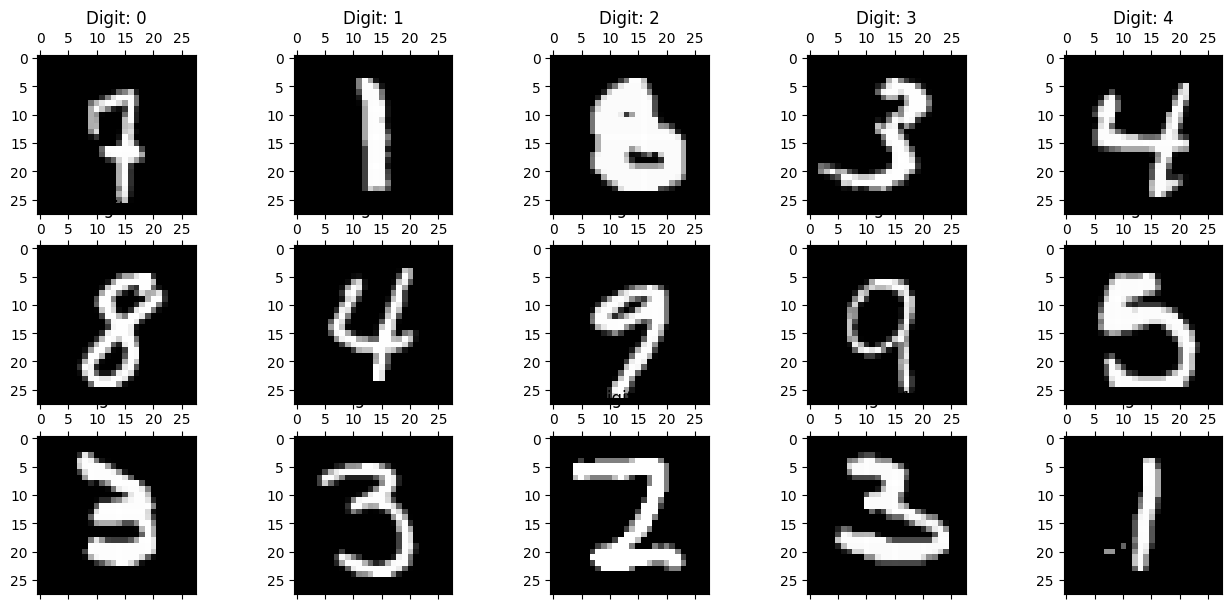

In [30]:
plt.gray()
fig = plt.figure( figsize=(16,7) )
for i in range(0,15):
    x = x_train[i]
    y = y_train[i]
    ax = fig.add_subplot(3,5,i+1, title="Digit: {}".format(str(i)))
    ax.matshow(x)
plt.show()


In [31]:
# we will just use the first 10000 samples
x_train_flatten = x_train.reshape(x_train.shape[0], np.prod(x_train.shape[1:]))
y_train_flatten = y_train.reshape(y_train.shape[0])
#x_train_flatten = x_train_flatten[0:1000]
#y_train_flatten = y_train_flatten[0:1000]
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_train_flatten)

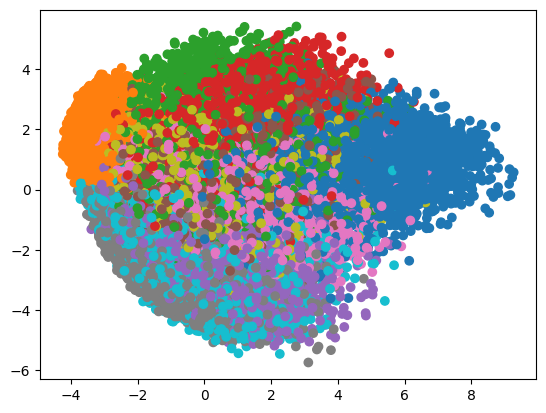

In [32]:
plt.scatter(pca_result[:,0], pca_result[:,1], c=y_train_flatten, cmap='tab10')

#ax = plt.figure(figsize=(16,10))#.gca(projection='3d')
#ax.scatter(
#    xs=pca_result[:,0], 
#    ys=pca_result[:,1], 
#    #zs=pca_result[:,2], 
#    c=y_train_flatten, 
#    cmap='tab10'
#)
#ax.set_xlabel('pca-one')
#ax.set_ylabel('pca-two')
#ax.set_zlabel('pca-three')
plt.show()

In [33]:
# tSNE is very expensive to compute. Let's use only 3000 samples
x_train_flatten = x_train_flatten[0:3000]
y_train_flatten = y_train_flatten[0:3000]
time_start = time.time()
tsne = TSNE(n_components=2, verbose=1, perplexity=40)#, n_iter=300)
tsne_results = tsne.fit_transform(x_train_flatten)
print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.006s...
[t-SNE] Computed neighbors for 3000 samples in 2.331s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 2.460943
[t-SNE] KL divergence after 250 iterations with early exaggeration: 77.076363
[t-SNE] KL divergence after 1000 iterations: 1.359684
t-SNE done! Time elapsed: 10.559370756149292 seconds


In [34]:
data = {"x{}".format(i): x_train_flatten[:, i] for i in range(x_train_flatten.shape[1])}
data["y"] = y_train_flatten
df = pd.DataFrame(data)

In [35]:
df

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x775,x776,x777,x778,x779,x780,x781,x782,x783,y
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
2996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
2998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8


<Axes: >

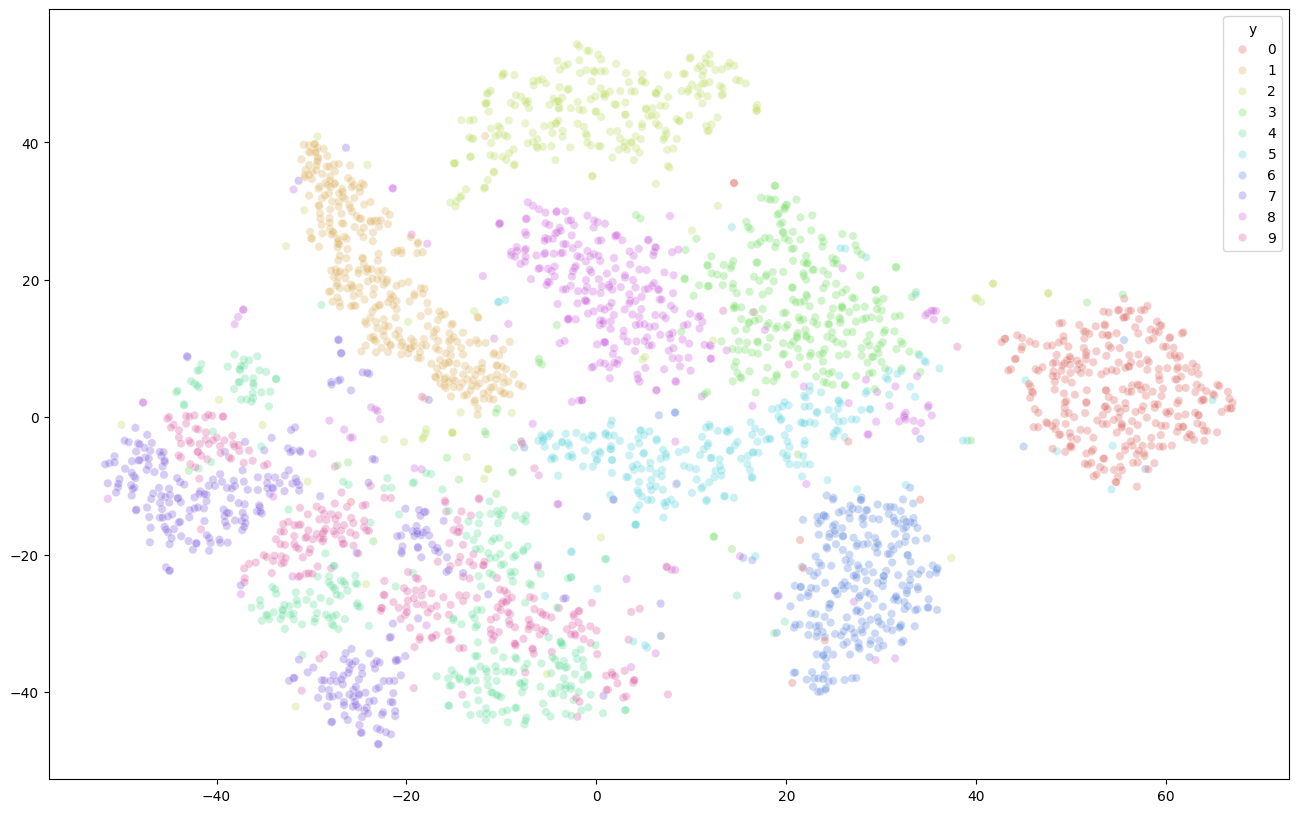

In [36]:
plt.figure(figsize=(16,10))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df,
    legend="full",
    alpha=0.3
)

In [37]:
pca_50 = PCA(n_components=50)
pca_result_50 = pca_50.fit_transform(x_train_flatten)
print('Cumulative explained variation for 50 principal components: {}'.format(np.sum(pca_50.explained_variance_ratio_)))

Cumulative explained variation for 50 principal components: 0.827924622252715


In [38]:
x_train_flatten.shape, y_train_flatten.shape, pca_result_50.shape

((3000, 784), (3000,), (3000, 50))

In [39]:
tsne = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300)
tsne_results = tsne.fit_transform(pca_result_50)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.002s...
[t-SNE] Computed neighbors for 3000 samples in 0.065s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 2.259060
[t-SNE] KL divergence after 250 iterations with early exaggeration: 76.718452
[t-SNE] KL divergence after 300 iterations: 1.974648


<Axes: >

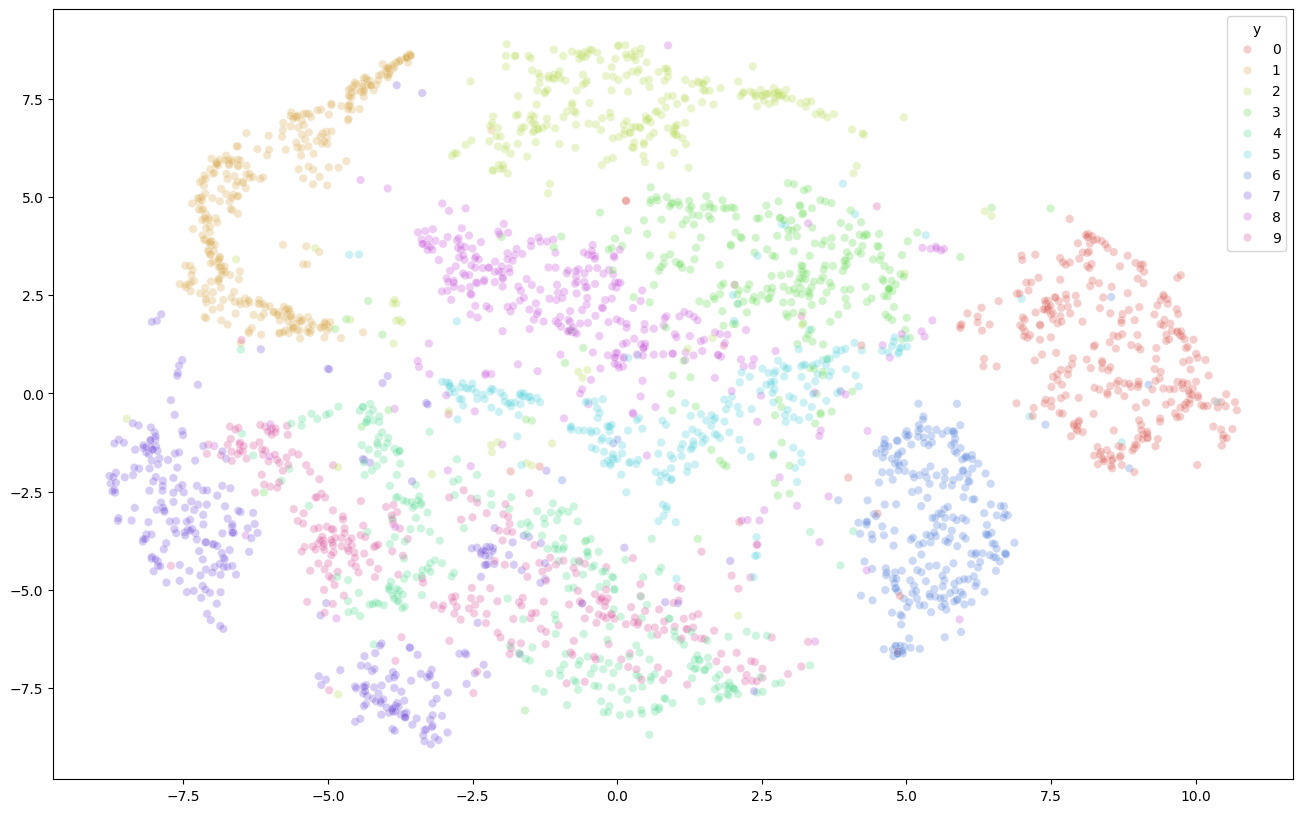

In [40]:
plt.figure(figsize=(16,10))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df,
    legend="full",
    alpha=0.3
)

Now, you will perform the same exercise on cifar10 or cifar100.

In [41]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [42]:
x_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [43]:
x_train = x_train / 255.0
indexes = x_train.shape[0]
indexes = np.random.permutation(indexes)
indexes

array([33189,  2319, 26502, ..., 23767, 44144,  5543],
      shape=(50000,), dtype=int32)

In [44]:
x_train = x_train[indexes]
y_train = y_train[indexes]

<Figure size 640x480 with 0 Axes>

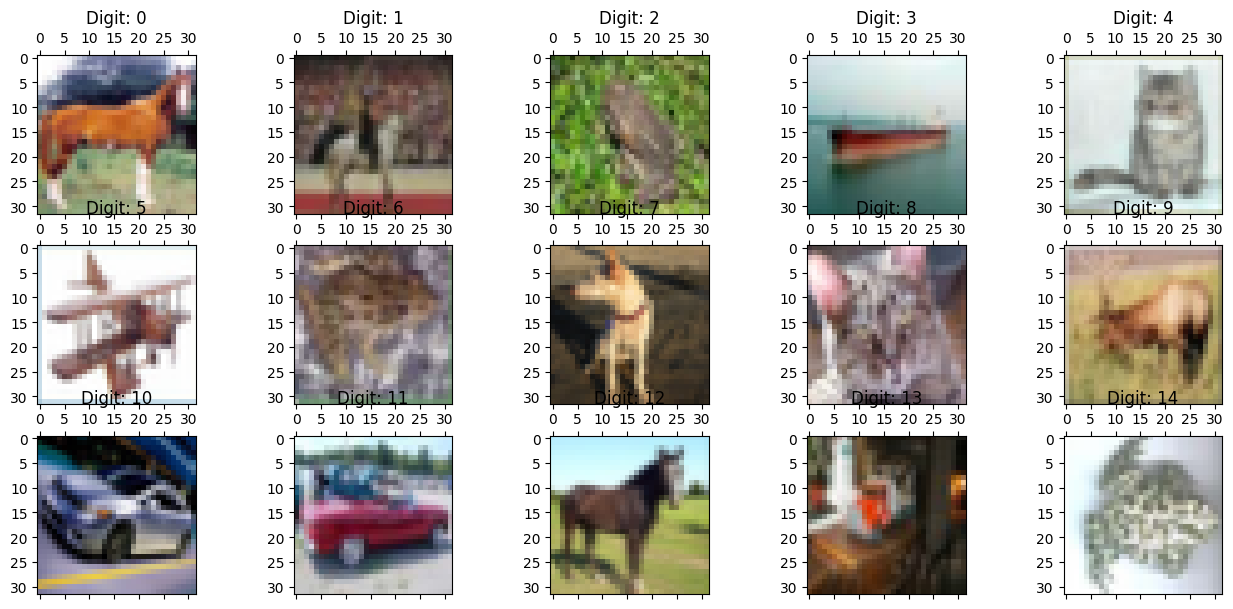

In [45]:
plt.gray()
fig = plt.figure( figsize=(16,7) )
for i in range(0,15):
    x = x_train[i]
    y = y_train[i]
    ax = fig.add_subplot(3,5,i+1, title="Digit: {}".format(str(i)))
    ax.matshow(x)
plt.show()

In [46]:
# we will just use the first 10000 samples
x_train_flatten = x_train.reshape(x_train.shape[0], np.prod(x_train.shape[1:]))
y_train_flatten = y_train.reshape(y_train.shape[0])
#x_train_flatten = x_train_flatten[0:1000]
#y_train_flatten = y_train_flatten[0:1000]
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_train_flatten)

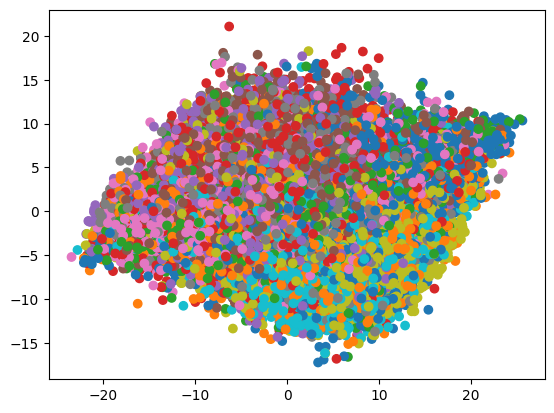

In [47]:
plt.scatter(pca_result[:,0], pca_result[:,1], c=y_train_flatten, cmap='tab10')

plt.show()

In [48]:
# tSNE is very expensive to compute. Let's use only 300 samples
x_train_flatten = x_train_flatten[0:3000]
y_train_flatten = y_train_flatten[0:3000]
time_start = time.time()
tsne = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300)
tsne_results = tsne.fit_transform(x_train_flatten)
print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.018s...
[t-SNE] Computed neighbors for 3000 samples in 0.439s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 3.456990
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.193146
[t-SNE] KL divergence after 300 iterations: 2.363106
t-SNE done! Time elapsed: 3.2519283294677734 seconds


<Axes: >

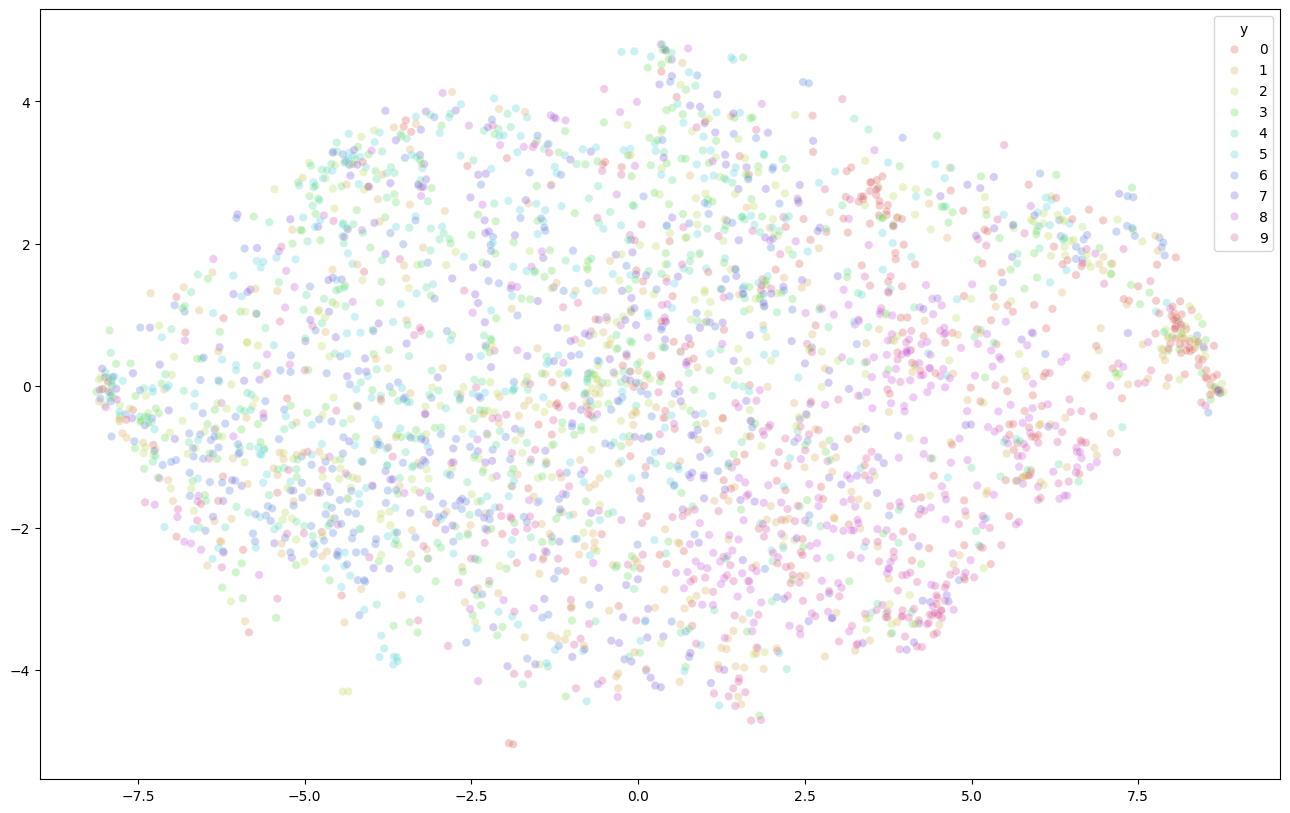

In [49]:
data = {"x{}".format(i): x_train_flatten[:, i] for i in range(x_train_flatten.shape[1])}
data["y"] = y_train_flatten
df = pd.DataFrame(data)

plt.figure(figsize=(16,10))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df,
    legend="full",
    alpha=0.3
)

We see much higher Intra-Class Invariance for Cifar10 due to the complexity of the data compared to MNIST. To learn this we will require convolutions.

With the help of ChatGPT, explain the difference among PCA (SVD if you remove mean(x) and compute np.dot(X.T, X) to create a square matrix), tSNE and UMAP, explaining how it works.  I will be checking if you left ChatGPT generating the sentences and it ended up writing garbage.

PCA, t-SNE, and UMAP are all ways to reduce high-dimensional data so it’s easier to see or analyze, but they do this in very different ways. PCA is the simplest: it looks for straight-line directions in the data where the values change the most, and projects the data onto those directions. It preserves overall trends and structure, but it cannot capture curved or complex patterns. t-SNE focuses on keeping similar points close together: it tries to make points that were neighbors in the original space stay neighbors in the lower-dimensional view. This makes clusters very clear, but distances between clusters and the overall layout are often distorted. UMAP also keeps nearby points together, but it additionally tries to preserve the broader shape of the data. As a result, UMAP usually shows both local groupings and some global structure, while being faster and more stable than t-SNE for large datasets.